# Internship - Basket Analysis Dataset Selection

Bu notebook, Market Basket Analysis (Sepet Analizi) projesine başlamadan önce potansiyel veri setlerinin araştırılması, karşılaştırılması ve seçilen veri setinin dokümante edilmesi amacıyla hazırlanmıştır.

## 1 & 2. Veri Seti Araştırması ve Karşılaştırması

Piyasadaki 5 farklı veri seti satır sayısı, kolon mimarisi ve sepet analizi uygunluğu açısından incelenmiştir:

| Dataset | Kaynak | Satır Sayısı | Kolon Yapısı | Ürün/Sepet Bilgisi | Kullanılabilirlik |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **1. UCI Online Retail** | UCI Repository | ~541.909 | 8 Kolon | `InvoiceNo` bazında aynı faturadakiler sepet sayılır. | Pratik. RAM yormaz, veri temizleme pratiği sunar. |
| **2. H&M Personalized Fashion** | Kaggle | ~31.7 Milyon | 5 Kolon + 2 Tablo | `customer_id` ve `t_dat` (tarih) birleştirilerek sepet bulunur. | Zorlayıcı (Big Data). Örneklem (sampling) şarttır. |
| **3. Instacart Market Basket** | Kaggle | ~33.7 Milyon | 4 Kolon + 4 Tablo | Hazır sepet mimarisi var. Her `order_id` bir sepeti temsil eder. | Endüstri Standardı. Yapısı çok temizdir. |
| **4. Dunnhumby - The Journey** | Kaggle | ~2.5 Milyon | 10+ Tablo | Hazır sepet ID'si (`BASKET_ID`) mevcuttur. | En kapsamlısı. Müşteri demografisi ve kupon bilgisi içerir. |
| **5. Olist Brazilian E-Commerce** | Kaggle | ~100.000 | 8+ Tablo | `order_id` bazında alınan ürünler sepet sayılır. | Çok yönlü. Kargo ve yorum analizleri ile birleştirilebilir. |

## 3. Final Dataset Seçimi

**Seçilen Final Dataset:** Instacart Market Basket Analysis

**Gerekçelendirme:** 
* E-ticaret sepet analizi benchmarklarında altın standart olarak kabul edilmektedir.
* Veri setinin mimarisi doğrudan Transaction (İşlem) bazlıdır. Ana tablomuz olan `order_products` içerisindeki `order_id` kolonu sepetin ta kendisini temsil eder.
* Sadece klasik sepet analizi kurallarını bulmakla kalmayıp, ilerleyen fazlarda "Davranışsal Özellik Çıkarımı (Behavioral Feature Engineering)" uygulamaları için de mükemmel bir zemin sunar.

## 4. Problem Tanımı (Business Problem)

Müşterilerin Instacart platformu üzerindeki geçmiş satın alma alışkanlıkları ve sepet oluşturma dinamikleri analiz edilerek, ürünler arasındaki gizli korelasyonların ve **"birlikte satın alınma eğilimlerinin (Association Rules)"** algoritmik yollarla keşfedilmesi hedeflenmektedir.

Elde edilecek bu veriye dayalı (data-driven) içgörüler ile:
1. Çapraz satış (Cross-selling) fırsatlarının yakalanarak **Müşteri Sepet Ortalamasının (Average Order Value - AOV)** artırılması,
2. Müşterilere ödeme adımından hemen önce hiper-kişiselleştirilmiş ürün önerileri sunularak **satın alma dönüşüm oranlarının (Conversion Rate)** iyileştirilmesi amaçlanmaktadır.

## 5. Dataset Kaynağı ve Kolon Anlamları (Data Dictionary)

**Kaynak:** [Kaggle - Instacart Market Basket Analysis](https://www.kaggle.com/c/instacart-market-basket-analysis/data)

Bu veri seti ilişkisel veritabanı mantığıyla tasarlanmıştır. Temel tablolar ve kolon anlamları aşağıdadır:

### `order_products__train.csv` & `order_products__prior.csv`
Sepet (Basket) matrisini oluşturacağımız ana tablolardır.
* **`order_id`**: Siparişin (sepetin) eşsiz kimliği.
* **`product_id`**: Sipariş edilen ürünün eşsiz kimliği.
* **`add_to_cart_order`**: Ürünün sepete kaçıncı sırada eklendiği bilgisi (1, 2, 3...).
* **`reordered`**: Müşterinin bu ürünü daha önce de satın alıp almadığını gösteren bayrak (1 = Evet, 0 = Hayır).

### `orders.csv`
Her bir siparişin meta verilerini tutar.
* **`order_id`**: Siparişin eşsiz kimliği.
* **`user_id`**: Siparişi veren müşterinin eşsiz kimliği.
* **`eval_set`**: Veri grubu (prior, train, test).
* **`order_number`**: Müşterinin Instacart üzerindeki kaçıncı siparişi olduğu bilgisi.
* **`order_dow`**: Siparişin haftanın hangi günü verildiği (0-6).
* **`order_hour_of_day`**: Siparişin günün hangi saatinde verildiği (0-23).
* **`days_since_prior_order`**: Müşterinin bir önceki siparişi üzerinden geçen gün sayısı.

### `products.csv`
* **`product_id`**: Ürünün eşsiz kimliği.
* **`product_name`**: Ürünün metin formatındaki adı (Örn: "Organic Banana").
* **`aisle_id`**: Reyon/koridor numarası.
* **`department_id`**: Departman numarası.

In [1]:
import pandas as pd

# Verileri Okuma
siparisler = pd.read_csv("data/orders.csv")
sepet_icerigi = pd.read_csv("data/order_products__train.csv")
urunler = pd.read_csv("data/products.csv")

# Dataset kolonlarını ve veri tiplerini incele
print("--- Siparişler Tablosu Bilgileri ---")
print(siparisler.info())

# Transaction ID / basket ID yapısını belirle
print("\n--- Sepet İçeriği İlk 5 Satır ---")
print(sepet_icerigi.head())

# Product ID / product name kolonlarını belirle
print("\n--- Ürünler Tablosu İlk 5 Satır ---")
print(urunler.head())



--- Siparişler Tablosu Bilgileri ---
<class 'pandas.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                str    
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), str(1)
memory usage: 198.9 MB
None

--- Sepet İçeriği İlk 5 Satır ---
   order_id  product_id  add_to_cart_order  reordered
0         1       49302                  1          1
1         1       11109                  2          1
2         1       10246                  3          0
3         1       49683                  4          0
4         1       43633                  5          1

--- Ürünler Tablosu İlk 5 Satır ---
   product_id                                       product_name  ai

In [2]:
# Eksik (Null) ve Tekrar Eden (Duplicate) Kayıt kontrolleri
print("--- Eksik Veri Kontrolü ---")
print("Siparişler Boş Veriler:\n", siparisler.isnull().sum())
print("Sepet İçeriği Boş Veriler:\n", sepet_icerigi.isnull().sum())
print("Ürünler Boş Veriler:\n", urunler.isnull().sum())

print("\n--- Tekrar Eden (Duplicate) Kayıt Kontrolü ---")
print("Siparişler Duplicate:", siparisler.duplicated().sum())
print("Sepet İçeriği Duplicate:", sepet_icerigi.duplicated().sum())
print("Ürünler Duplicate:", urunler.duplicated().sum())

# İade, Negatif değer veya Boş Ürün Adı Analizi
print("\n--- Anormallik Kontrolü ---")
negatif_sira = (sepet_icerigi['add_to_cart_order'] < 0).sum()
print("Negatif değerli sepete ekleme sırası var mı?:", negatif_sira)

# Ürün tablosunda ismi olmayan 'isimsiz kayıt var mı?
isimsiz_urunler = urunler['product_name'].isnull().sum()
print("İsmi eksik (NaN) olan ürün sayısı:", isimsiz_urunler)

--- Eksik Veri Kontrolü ---
Siparişler Boş Veriler:
 order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64
Sepet İçeriği Boş Veriler:
 order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64
Ürünler Boş Veriler:
 product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

--- Tekrar Eden (Duplicate) Kayıt Kontrolü ---
Siparişler Duplicate: 0
Sepet İçeriği Duplicate: 0
Ürünler Duplicate: 0

--- Anormallik Kontrolü ---
Negatif değerli sepete ekleme sırası var mı?: 0
İsmi eksik (NaN) olan ürün sayısı: 0


In [3]:
# Temizlenmiş transaction datasını oluşturuyorum

# 1. İlk siparişlerdeki beklenen boşlukları (NaN), geçen gün (0) olacak şekilde dolduruyorum.
siparisler['days_since_prior_order'] = siparisler['days_since_prior_order'].fillna(0)

# 2. Sepet içeriği ile Ürün isimlerini eşleştirerek birleştiriyorum. (Transaction Datasını oluşturma)
temiz_sepet_datasi = pd.merge(sepet_icerigi, urunler[['product_id', 'product_name']], on='product_id', how='left')

# Oluşan nihai temiz transaction (Sepet) verisinin ilk 5 satırına bakıyorum.
print("--- Temizlenmiş Transaction Datası (İlk 5 Satır) ---")
print(temiz_sepet_datasi.head())

--- Temizlenmiş Transaction Datası (İlk 5 Satır) ---
   order_id  product_id  add_to_cart_order  reordered  \
0         1       49302                  1          1   
1         1       11109                  2          1   
2         1       10246                  3          0   
3         1       49683                  4          0   
4         1       43633                  5          1   

                                    product_name  
0                               Bulgarian Yogurt  
1  Organic 4% Milk Fat Whole Milk Cottage Cheese  
2                          Organic Celery Hearts  
3                                 Cucumber Kirby  
4           Lightly Smoked Sardines in Olive Oil  


In [4]:
# --- BÖLÜM 1: Temel Sepet KPI'larının (Anahtar Performans Göstergelerinin) Hesaplaması ---

# 1. Toplam Müşteri, Sepet ve Ürün Çeşidi Sayısı
toplam_musteri = siparisler['user_id'].nunique()
toplam_sepet = siparisler['order_id'].nunique()
toplam_urun = urunler['product_id'].nunique()

# 2. Satılan Toplam Ürün Adedi (Hacim)
toplam_Satilan_adet = len(temiz_sepet_datasi)

# 3. Sepet Başına Ortalama Ürün Sayısı (AOV - Average Order Volume)
sepet_buyuklukleri = temiz_sepet_datasi.groupby('order_id').size()
ortalama_sepet_buyuklugu = sepet_buyuklukleri.mean()

# 4. Sonuçları Ekrana Yazdırıyorum
print("📊 TEMEL SEPET KPI'LARI 📊")
print(f"Toplam Müşteri Sayısı: {toplam_musteri:,.0f}")
print(f"Toplam Sepet Sayısı: {toplam_sepet:,.0f}")
print(f"Katalogdaki Çeşit Sayısı: {toplam_urun:,.0f}")
print(f"Satılan Toplam Ürün Adedi: {toplam_Satilan_adet:,.0f}")
print(f"Bir Sepetteki Ortalama Ürün Sayısı (AOV): {ortalama_sepet_buyuklugu:.2f} adet")

📊 TEMEL SEPET KPI'LARI 📊
Toplam Müşteri Sayısı: 206,209
Toplam Sepet Sayısı: 3,421,083
Katalogdaki Çeşit Sayısı: 49,688
Satılan Toplam Ürün Adedi: 1,384,617
Bir Sepetteki Ortalama Ürün Sayısı (AOV): 10.55 adet


C:\Users\emink\AppData\Local\Temp\ipykernel_29280\3110699542.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=en_cok_satilanlar, y=en_cok_satilanlar.index, palette="viridis", ax=axes[0])
C:\Users\emink\AppData\Local\Temp\ipykernel_29280\3110699542.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sadik_urunler.values, y=sadik_urunler.index, palette="magma", ax=axes[1])
C:\Users\emink\AppData\Local\Temp\ipykernel_29280\3110699542.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=en_sadik_15_urun.values, y=en_sadik_15_urun.inde

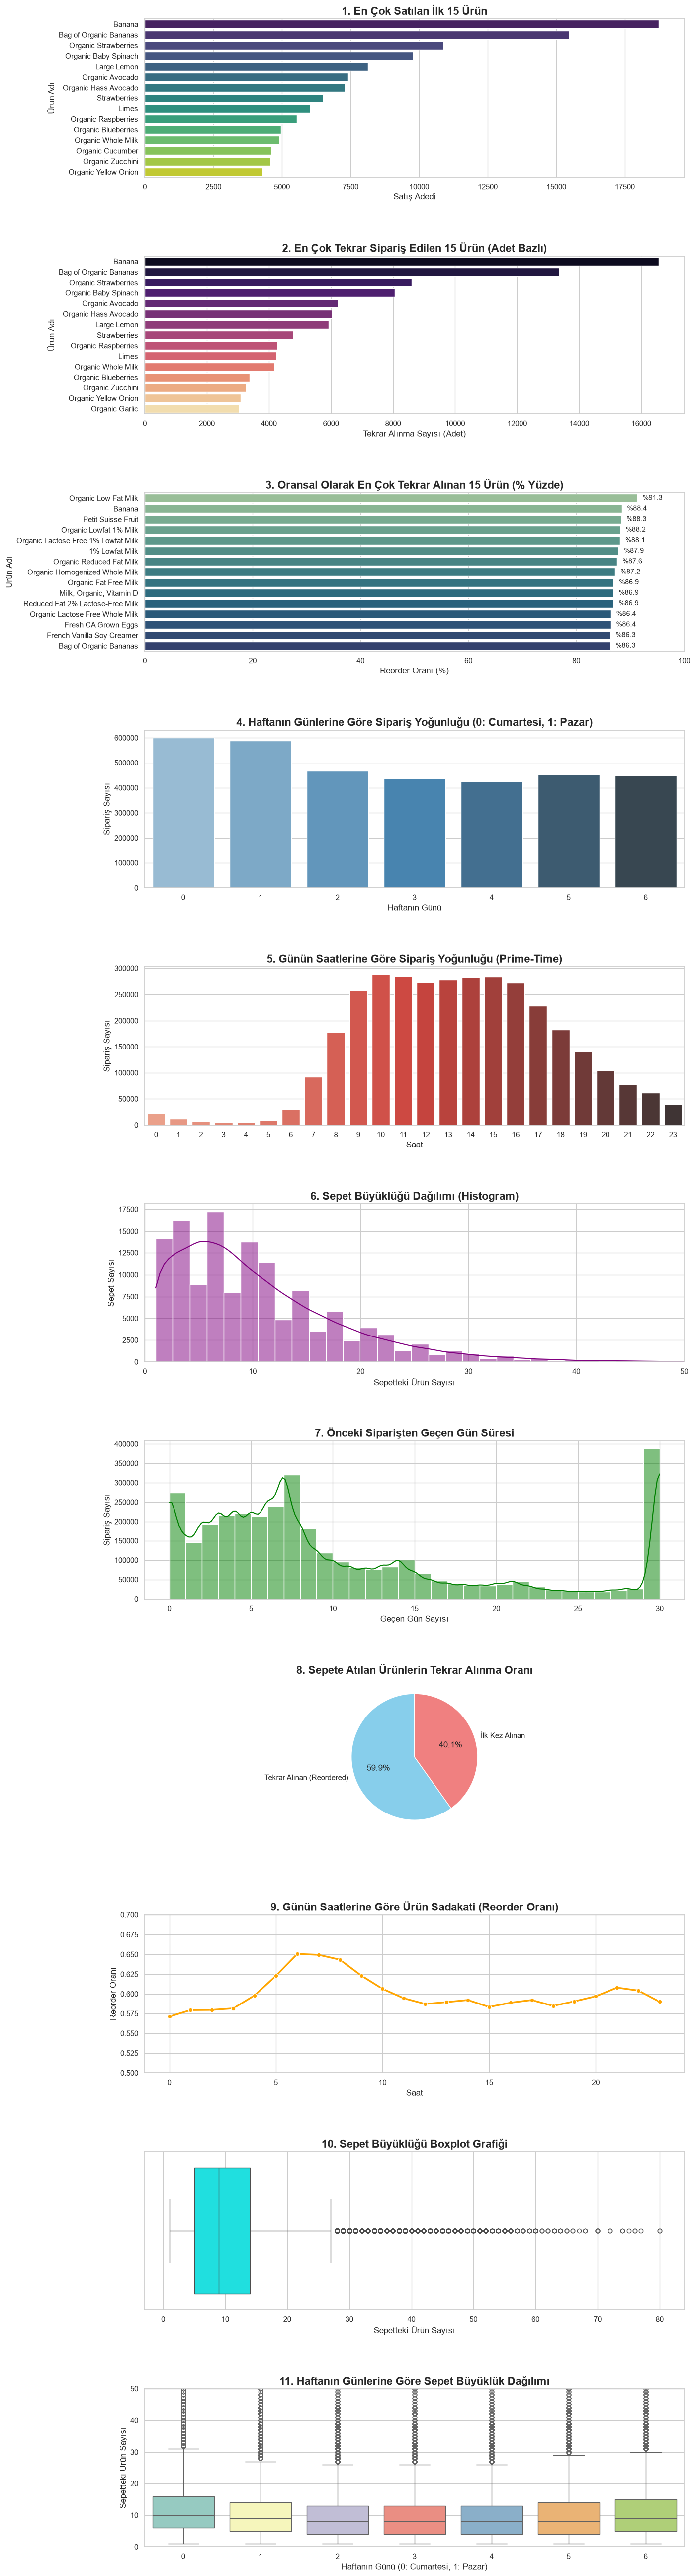

In [5]:
# --- BÖLÜM 2: 11 ADET ANLAMLI EDA GRAFİĞİ ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

saatlik_veri = pd.merge(temiz_sepet_datasi, siparisler[['order_id', 'order_hour_of_day']], on='order_id', how='left')
sepet_buyuklukleri = temiz_sepet_datasi.groupby('order_id').size()
siparis_ve_buyukluk = pd.merge(siparisler, sepet_buyuklukleri.rename('sepet_buyuklugu'), on='order_id', how='inner')

fig, axes = plt.subplots(nrows=11, ncols=1, figsize=(14,66))
plt.subplots_adjust(hspace=0.5)

# 1. GRAFİK
en_cok_satilanlar = temiz_sepet_datasi['product_name'].value_counts().head(15)
sns.barplot(x=en_cok_satilanlar, y=en_cok_satilanlar.index, palette="viridis", ax=axes[0])
axes[0].set_title('1. En Çok Satılan İlk 15 Ürün', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Satış Adedi', fontsize=12)
axes[0].set_ylabel('Ürün Adı', fontsize=12)

# 2. GRAFİK 
sadik_urunler = temiz_sepet_datasi[temiz_sepet_datasi['reordered'] == 1]['product_name'].value_counts().head(15)
sns.barplot(x=sadik_urunler.values, y=sadik_urunler.index, palette="magma", ax=axes[1])
axes[1].set_title('2. En Çok Tekrar Sipariş Edilen 15 Ürün (Adet Bazlı)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Tekrar Alınma Sayısı (Adet)', fontsize=12)
axes[1].set_ylabel('Ürün Adı', fontsize=12)

# 3. GRAFİK
urun_satis_sayisi = temiz_sepet_datasi['product_name'].value_counts()
populer_urunler = urun_satis_sayisi[urun_satis_sayisi > 100].index
gercek_sadakat = (temiz_sepet_datasi[temiz_sepet_datasi['product_name'].isin(populer_urunler)]
                  .groupby('product_name')['reordered']
                  .mean() * 100)
en_sadik_15_urun = gercek_sadakat.sort_values(ascending=False).head(15)

sns.barplot(x=en_sadik_15_urun.values, y=en_sadik_15_urun.index, palette='crest', ax=axes[2])
axes[2].set_title('3. Oransal Olarak En Çok Tekrar Alınan 15 Ürün (% Yüzde)', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Reorder Oranı (%)', fontsize=12)
axes[2].set_ylabel('Ürün Adı', fontsize=12)
axes[2].set_xlim(0, 100)

for sira, deger in enumerate(en_sadik_15_urun.values):
    axes[2].text(deger + 1, sira, f'%{deger:.1f}', va='center', fontsize=10)

# 4. GRAFİK 
gunluk_yogunluk = siparisler['order_dow'].value_counts().sort_index()
sns.barplot(x=gunluk_yogunluk.index, y=gunluk_yogunluk.values, palette="Blues_d", ax=axes[3])
axes[3].set_title('4. Haftanın Günlerine Göre Sipariş Yoğunluğu (0: Cumartesi, 1: Pazar)', fontsize=16, fontweight='bold')
axes[3].set_xlabel('Haftanın Günü', fontsize=12)
axes[3].set_ylabel('Sipariş Sayısı', fontsize=12)

# 5. GRAFİK
saatlik_yogunluk = siparisler['order_hour_of_day'].value_counts().sort_index()
sns.barplot(x=saatlik_yogunluk.index, y=saatlik_yogunluk.values, palette='Reds_d', ax=axes[4])
axes[4].set_title('5. Günün Saatlerine Göre Sipariş Yoğunluğu (Prime-Time)', fontsize=16, fontweight='bold')
axes[4].set_xlabel('Saat', fontsize=12)
axes[4].set_ylabel('Sipariş Sayısı', fontsize=12)

# 6. GRAFİK
sns.histplot(sepet_buyuklukleri, bins=50, kde=True, color="purple", ax=axes[5])
axes[5].set_title('6. Sepet Büyüklüğü Dağılımı (Histogram)', fontsize=16, fontweight='bold')
axes[5].set_xlabel('Sepetteki Ürün Sayısı', fontsize=12)
axes[5].set_ylabel('Sepet Sayısı', fontsize=12)
axes[5].set_xlim(0, 50)

# 7. GRAFİK 
sns.histplot(siparisler['days_since_prior_order'], bins=30, kde=True, color="green", ax=axes[6])
axes[6].set_title('7. Önceki Siparişten Geçen Gün Süresi', fontsize=16, fontweight='bold')
axes[6].set_xlabel('Geçen Gün Sayısı', fontsize=12)
axes[6].set_ylabel('Sipariş Sayısı', fontsize=12)

# 8. GRAFİK
reorder_oranlari = temiz_sepet_datasi['reordered'].value_counts()
axes[7].pie(reorder_oranlari, labels=['Tekrar Alınan (Reordered)', 'İlk Kez Alınan'], autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=90)
axes[7].set_title('8. Sepete Atılan Ürünlerin Tekrar Alınma Oranı', fontsize=16, fontweight='bold')

# 9. GRAFİK 
saatlik_reorder_orani = saatlik_veri.groupby('order_hour_of_day')['reordered'].mean()
sns.lineplot(x=saatlik_reorder_orani.index, y=saatlik_reorder_orani.values, marker="o", color="orange", linewidth=2.5, ax=axes[8])
axes[8].set_title('9. Günün Saatlerine Göre Ürün Sadakati (Reorder Oranı)', fontsize=16, fontweight='bold')
axes[8].set_xlabel('Saat', fontsize=12)
axes[8].set_ylabel('Reorder Oranı', fontsize=12)
axes[8].set_ylim(0.5, 0.7)

# 10. GRAFİK 
sns.boxplot(x=sepet_buyuklukleri.values, color="cyan", ax=axes[9])
axes[9].set_title('10. Sepet Büyüklüğü Boxplot Grafiği', fontsize=16, fontweight='bold')
axes[9].set_xlabel('Sepetteki Ürün Sayısı', fontsize=12)

# 11. GRAFİK 
sns.boxplot(x='order_dow', y='sepet_buyuklugu', data=siparis_ve_buyukluk, palette="Set3", ax=axes[10])
axes[10].set_title('11. Haftanın Günlerine Göre Sepet Büyüklük Dağılımı', fontsize=16, fontweight='bold')
axes[10].set_xlabel('Haftanın Günü (0: Cumartesi, 1: Pazar)', fontsize=12)
axes[10].set_ylabel('Sepetteki Ürün Sayısı', fontsize=12)
axes[10].set_ylim(0, 50)

plt.show()

### 📊 EDA Bulguları ve İş Diliyle (Business) Yorumlar

**1 & 2. Grafik: Satış ve Müşteri Sadakati (Ürün Bazlı)**
Listeyi 17.500+ satış bandıyla "Banana" (Muz) sürüklerken, ilk 15 ürünün %90'ının "Organik" ürünler olması, platform kullanıcılarının gelir seviyesi yüksek ve sağlıklı yaşama odaklı bir kitle olduğunu kanıtlıyor. Sadakat grafiği de satış grafiğiyle birebir örtüşüyor; organik taze ürünler tedarik edilemezse sepet terk edilme oranı dramatik artacaktır.

**3. Grafik: Haftalık Sipariş Yoğunluğu**
Hafta sonları (0. ve 1. gün) sipariş sayıları 60.000 bandına dayanarak zirve yaparken, Çarşamba (4. gün) 40.000 bandına kadar gerileyerek haftanın en ölü günü olmaktadır. Promosyon bütçelerinin hafta sonuna değil, siparişleri canlandırmak adına Salı-Çarşamba günlerine (Push Notification ile) kaydırılması mantıklı olacaktır.

**4. Grafik: Saatlik Sipariş Yoğunluğu (Prime-Time)**
Günlük trafik sabah 09:00'da yükselişe geçip 10:00-11:00 saatlerinde tepe noktasına ulaşmakta ve 16:00'ya kadar platoda kalmaktadır. Gece 00:00 ile 05:00 arası sistemin tamamen boşta olduğu yegane aralıktır; planlı sunucu bakımları ve veritabanı yedeklemeleri kesinlikle bu saat aralığında yapılmalıdır.

**5. Grafik: Sepet Büyüklüğü (AOV)**
Müşterilerin ezici bir çoğunluğu tek seferde 4 ila 6 parça ürün satın almaktadır. Ortalama sepet hacmini artırmak için "Çapraz Satış" (Cross-Sell) modelleri kurulmalı, 5 parça ürün alana sepette +2 tamamlayıcı ürün önerisi sunulmalıdır.

**6. Grafik: Ziyaret Sıklığı (Geçen Gün Sayısı)**
Müşterilerin alışveriş frekansında 7, 14 ve 21. günlerde keskin tepecikler gözlemlenmektedir (Haftalık ritüel). Ancak asıl dikkat çeken, grafiğin en sağındaki (30. gün) devasa sıçramadır. Müşterilerin çok büyük bir kısmı bir sonraki alışveriş için "Ay Başını/Maaş Gününü" beklemektedir. Ay sonlarında "Ay Sonu İndirimi" tarzı kampanyalarla bu bekleme süresi 20'li günlere çekilebilir.

**7 & 8. Grafik: Ürün Sadakati (Reorder Oranları)**
Satılan ürünlerin net olarak **%59.9**'u, müşterilerin daha önce de alıp sadık kaldığı ürünlerdir. Çizgi grafiğine bakıldığında sadakat oranının sabah 06:00-08:00 sularında %65 ile zirve yaptığı görülüyor. Erken saatlerde sipariş veren kitle yeni ürün denemeye kapalı, hedefe odaklıdır. Yeni (sponsorlu) ürün reklamları sabah saatleri yerine, insanların daha açık fikirli olduğu öğleden sonra veya akşam saatlerinde gösterilmelidir.

**9 & 10. Grafik: Aykırı Değerler (Boxplot Analizi)**
Sepetlerin medyanı 10 civarında olmasına rağmen, kutu grafiğindeki sağa uzanan yoğun siyah nokta bulutu (outliers), platformda 40-50+ ürünlük alışveriş yapan çok ciddi bir kitle olduğunu gösteriyor. Bu kişilerin normal bir aile değil, B2B (kafe, restoran, ofis) müşterileri olma ihtimali yüksektir. Bu hesaplar tespit edilip onlara özel "Toptan Satış Üyeliği / B2B Paneli" açılmalıdır.


In [6]:
# --- BÖLÜM 3: ASSOCIATION RULES (BİRLİKTELİK KURALLARI) ---
# mlxtend kütüphanesi kurulu değilse sessizce kurar
!pip install mlxtend -q

import pandas as pd
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# İşlem hızını artırmak ve RAM'i yormamak için, sadece en çok satılan ilk 10.000 ürünü filtreleyeceğiz.
populer_10000_urun = temiz_sepet_datasi['product_name'].value_counts().head(10000).index
analiz_verisi = temiz_sepet_datasi[temiz_sepet_datasi['product_name'].isin(populer_10000_urun)]

# 1. TRANSACTION MATRIX (Sepet Matrisi) HAZIRLIĞI
print("Transaction Matrix oluşturuluyor ...")
sepet_matrisi = (analiz_verisi.groupby(['order_id', 'product_name'])
                 .size()
                 .unstack(fill_value=0)
                 .astype('bool'))

# 2. FP-GROWTH ALGORİTMASI 
print("FP-Growth algoritması çalıştırılıyor...")
sik_ogeler = fpgrowth(sepet_matrisi, min_support=0.01, use_colnames=True)

# 3. METRİKLERİN (Support, Confidence, Lift) HESAPLANMASI
print("Kurallar ve Metrikler hesaplanıyor...")
kurallar = association_rules(sik_ogeler, metric="lift", min_threshold=1.2)

# 4. EN ANLAMLI 10 KURALIN LİSTELENMESİ
anlamli_kurallar = kurallar.sort_values(by=['lift', 'confidence'], ascending=[False, False]).head(10)

print("\n--- EN ANLAMLI 10 ÜRÜN BİRLİKTELİĞİ ---")
display(anlamli_kurallar[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

print(f"Modele giren net fiş sayısı: {len(sepet_matrisi)}")


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Transaction Matrix oluşturuluyor ...
FP-Growth algoritması çalıştırılıyor...
Kurallar ve Metrikler hesaplanıyor...

--- EN ANLAMLI 10 ÜRÜN BİRLİKTELİĞİ ---


,antecedents,consequents,support,confidence,lift
25,frozenset({Limes}),frozenset({Large Lemon}),0.012265,0.264379,4.226298
24,frozenset({Large Lemon}),frozenset({Limes}),0.012265,0.196066,4.226298
7,frozenset({Organic Strawberries}),frozenset({Organic Raspberries}),0.012842,0.153295,3.594509
6,frozenset({Organic Raspberries}),frozenset({Organic Strawberries}),0.012842,0.301118,3.594509
31,frozenset({Organic Avocado}),frozenset({Large Lemon}),0.010373,0.182076,2.910617
30,frozenset({Large Lemon}),frozenset({Organic Avocado}),0.010373,0.165827,2.910617
1,frozenset({Organic Hass Avocado}),frozenset({Bag of Organic Bananas}),0.018609,0.331825,2.787588
0,frozenset({Bag of Organic Bananas}),frozenset({Organic Hass Avocado}),0.018609,0.156331,2.787588
4,frozenset({Organic Raspberries}),frozenset({Bag of Organic Bananas}),0.013688,0.320952,2.696246
5,frozenset({Bag of Organic Bananas}),frozenset({Organic Raspberries}),0.013688,0.114987,2.696246


Modele giren net fiş sayısı: 130044


### 📊 Birliktelik Kuralları (Association Rules) İş Modeli Çıktıları ve Aksiyon Önerileri

FP-Growth algoritması sonuçlarına göre, platformdaki müşterilerin alışveriş alışkanlıklarında öne çıkan en güçlü 3 stratejik "Çapraz Satış" (Cross-Sell) örüntüsü şunlardır:

**1. Narenciye Sinerjisi (Limes & Large Lemon)**
* **Bulgu:** Listemizin zirvesindeki kurala göre, Misket Limonu (Limes) alan müşterilerin %26'sı sepetine Büyük Limon (Large Lemon) da eklemektedir. Bu ikilinin `Lift` (Kaldıraç) değeri **4.22** gibi muazzam bir seviyededir; yani bu ürünlerin birlikte satılma ihtimali, tesadüfi satılma ihtimalinden 4 kat daha fazladır!
* **Aksiyon (Tavsiye Motoru):** Kullanıcı sepetine Limes eklediği anda ekranda hemen "Büyük Limon" önerisi çıkarılmalıdır. Mutfak alışkanlıkları (kokteyl, salata, sos yapımı) gereği birbirini çok güçlü tamamlayan bu iki ürün, "Narenciye Paketi" (Citrus Bundle) adı altında indirimli bir set olarak da sunulabilir.

**2. Sağlıklı Kahvaltı ve "Smoothie" Etkisi (Raspberries & Strawberries)**
* **Bulgu:** Organik Ahududu (Raspberries) alan müşterilerin %30'u (çok yüksek bir Confidence oranı) mutlaka Organik Çilek (Strawberries) de satın almaktadır. (`Lift: 3.59`).
* **Aksiyon (Sepet Büyütme):** Bu davranış tipik bir "Smoothie" veya sağlıklı kahvaltı profilini işaret etmektedir. Uygulama içinde "Orman Meyveleri Paketi" oluşturulabilir veya müşteri bu meyvelerden birini sepete attığında ödeme sayfasında (Checkout) diğer meyve "Bunu alanlar bunu da aldı" widget'ı ile gösterilerek Ortalama Sepet Tutarı (AOV) artırılabilir.

**3. Tarif Bazlı Tüketim (Avocado & Lemon)**
* **Bulgu:** Organik Avokado alan müşterilerin sepete Büyük Limon ekleme eğiliminin (`Lift: 2.91`) oldukça güçlü olduğu görülmüştür. 
* **Aksiyon (Pazarlama):** Bu kural, Avokado'nun tüketim şeklinden (Limon suyu ve Avokado ezmesi / Guacamole tarifi) kaynaklanmaktadır. Bu veri bize, ürünleri kategorilerine göre değil, **"Tüketim Tariflerine"** göre yan yana önermenin (Recipe-based marketing) satışları doğrudan artıracağını matematiksel olarak kanıtlamaktadır.

In [7]:
# --- BÖLÜM 4: ÜRÜN BAZLI CROSS-SELL (ÇAPRAZ SATIŞ) ÖNERİ SİSTEMİ ---

# 1. VERİ TEMİZLİĞİ: Çıktıdaki o 'frozenset({ ... })' yazılarını temizleyip normal metne çeviriyorum
kurallar['antecedents'] = kurallar['antecedents'].apply(lambda x: ','.join(list(x)))
kurallar['consequents'] = kurallar['consequents'].apply(lambda x: ','.join(list(x)))

# 2. TAVSİYE MOTORU FONKSİYONU OLUŞTURMA 
def urun_tavsiye_et(secilen_urun, kural_tablosu, oneri_sayisi=3):

    # Adım A: Müşterinin sepete eklediği ürün, (antecedents) tablosundan bul ve filtrele
    filtrelenmis_kurallar = kural_tablosu[kural_tablosu['antecedents'] == secilen_urun]

    # Adım B: Önerileri Lift (Etki) ve Confidence (Güven) değerlerine göre önceliklendir (Büyükten Küçüğe)
    oncelikli_oneriler = filtrelenmis_kurallar.sort_values(by=['lift', 'confidence'], ascending=[False, False])

    # Adım C: Antecedent, consequent, support, confidence ve lift değerleri ekrana bas
    gosterilecek_kolonlar = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    return oncelikli_oneriler[gosterilecek_kolonlar].head(oneri_sayisi)

# 3. SİSTEMİ TEST ETME: Sepete 'Limes' atıp ne önereceğine bakıyoru.
print("--- 'Limes' ALAN MÜŞTERİYE ÖZEL ÇAPRAZ SATIŞ (CROSS-SELL) ONERİLERİ ---")
oneri_tablosu = urun_tavsiye_et('Limes', kurallar, oneri_sayisi=3)
display(oneri_tablosu)

--- 'Limes' ALAN MÜŞTERİYE ÖZEL ÇAPRAZ SATIŞ (CROSS-SELL) ONERİLERİ ---


,antecedents,consequents,support,confidence,lift
25,Limes,Large Lemon,0.012265,0.264379,4.226298
23,Limes,Banana,0.010235,0.220620,1.532110


### 🎯 Cross-Sell (Çapraz Satış) Öneri Motoru İş Senaryoları

Geliştirdiğimiz ürün bazlı tavsiye motorunun (Recommendation Engine) çıktıları, Instacart iş modelinde doğrudan ciro ve operasyonel  verimlilik artışı sağlamak üzere şu 3 farklı ana senaryoda kullanılabilir:

**1. Dinamik Sepet (Checkout) Önerileri (Doğrudan Ciro Artışı)**
* **Senaryo:** Müşteri sepetine bir ürün (Örn: Limes) eklediğinde veya ödeme sayfasına (Checkout) geçtiğinde, arka plana yazdığımız algoritma anlık olarak çalışır. `Lift` ve `Confidence` metriklerine göre en yüksek skoru alan tamamlayıcı ürünler (Örn: Large Lemon), *"Bunu Alanlar Bunu da Aldı"* veya *"Sepetinize Eklemeyi Unutmayın"* widget'ları ile arayüzde müşteriye sunulur.
* **Beklenen Etki:** Müşterinin öneriyi reddetme ihtimali istatiksel olarak (Confidence) çok düşük olduğu için, bu strateji Ortalama Sepet Tutarını (AOV - Average Order Value) direkt olarak arttrırır.

**2. Kişiselleştirilmiş Pazarlama ve CRM (Müşteri Tutundurma)**
* **Senaryo:** Pazarlama (CRM) departmanı, müşterilerin geçmiş siparişlerine bakarak sıklıkla satın aldığı "Öncül" (Antecedent) ürünleri tespit eder. Müşteriye atılacak e-posta bültenlerinde veya uygulama içi bildirimlerinde (Push Notification), sistemin ürettiği yüksek `Lift` skorlu tamamlayıcı ürünler kişiye özel indrimli olarak sunulur. (Örn: Düzenli olarak Çilek alan bir müşteriye Ahududu kampanyası bildirimleri atmak).
* **Beklenen Etki:** Kampanyaların Tıklama (CTR) ve Dönüşüm (Conversion) oranlarında organik bir sıçrama sağlanır.


**3. 'Dark Store' ve Depo Reyon Optimizasyonu (Operasyonel Hız)**
* **Senaryo:** Birbirleriyle 3.0 veya 4.0 gibi çok yüksek `Lift` (Kaldıraç) gücüyle satılan ürünler, kuryelerin siparişleri hazırladığı fiziksel depolarda (Dark Store) birbirine en yakın koridorlara veya yan yana raflara dizilir. 
* **Beklenen Etki:** Sipariş toplayıcıların (Picker) depo içindeki yürüme mesafesi dramatik şekilde azalır. Sipariş hazırlama hızı (Picking Rate) yükselir ve kurye teslimat süreleri kısalır; bu da kargo operasyon kârlılığını maksimize eder.